# Session 17: Evaluating Imbalanced Classification Models
### Credit Card Fraud Detection Case Study

In real-world fraud detection, medical diagnosis, and cybersecurity, datasets are **heavily imbalanced**—the positive class (e.g., fraud, rare disease, cyberattack) constitutes only a tiny fraction of the total observations. Standard evaluation metrics like raw accuracy can be deceptively high and dangerously misleading.

This notebook covers:
1. **Dataset Creation & Logistic Regression**: Building and training a classifier on an imbalanced credit card fraud dataset.
2. **ROC Curve & AUC Score**: Plotting the Receiver Operating Characteristic curve and computing the Area Under the Curve.
3. **Precision-Recall Curve**: Visualizing precision vs. recall trade-offs and explaining its superiority for imbalanced data.
4. **Log Loss (Cross-Entropy Loss)**: Measuring probabilistic prediction confidence and penalty for misclassification.
5. **Simulating Extreme Class Imbalance (2% Fraud)**: Comparing how Accuracy, AUC, and Log Loss behave, and identifying the most misleading metric.


---
## Question 1: Dataset Preparation & Logistic Regression Classifier

### Problem Statement
Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using `scikit-learn`.

### Workflow
1. We construct a realistic credit card transactions dataset modeled after the popular Kaggle/ULB Credit Card Fraud dataset:
   - Features include `Time`, transaction `Amount`, and PCA-transformed behavioral features `V1` through `V10`.
   - The dataset features an imbalanced class distribution (~5% fraud, 95% legitimate).
2. Save the data to `credit_card_fraud.csv`.
3. Perform a stratified train-test split (80/20) to ensure both splits preserve the minority class ratio.
4. Scale continuous features using `StandardScaler` and train a `LogisticRegression` classifier.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    log_loss, confusion_matrix, classification_report
)

# Set visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Generate realistic imbalanced credit card dataset
np.random.seed(42)
n_samples = 4000
weights = [0.95, 0.05]  # 95% Legitimate (0), 5% Fraudulent (1)

X_synth, y_synth = make_classification(
    n_samples=n_samples,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    weights=weights,
    flip_y=0.01,
    random_state=42
)

# Construct realistic column names similar to Kaggle Credit Card dataset
feature_names = [f'V{i+1}' for i in range(10)]
df_fraud = pd.DataFrame(X_synth, columns=feature_names)

# Add realistic Time and Amount features
df_fraud['Time'] = np.sort(np.random.uniform(0, 172800, size=n_samples))  # 48 hours in seconds
amounts = np.where(y_synth == 1, 
                   np.random.exponential(scale=180, size=n_samples), 
                   np.random.exponential(scale=65, size=n_samples))
df_fraud['Amount'] = np.round(amounts + 1.0, 2)
df_fraud['Class'] = y_synth

# Save to CSV for workspace reference
csv_path = 'credit_card_fraud.csv'
df_fraud.to_csv(csv_path, index=False)
print(f"Saved credit card fraud dataset to '{csv_path}'.")
print(f"Dataset shape: {df_fraud.shape}")
print(f"Class distribution:\n{df_fraud['Class'].value_counts(normalize=True).map('{:.2%}'.format)}")

# 2. Features and Target
X = df_fraud.drop('Class', axis=1)
y = df_fraud['Class']

# 3. Stratified Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities and classes
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\nModel Training Complete.")
print(f"Test Set Total: {len(y_test)} transactions")
print(f"  • Actual Legitimate (0): {sum(y_test == 0)}")
print(f"  • Actual Fraud (1)     : {sum(y_test == 1)}")
print(f"Initial Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Saved credit card fraud dataset to 'credit_card_fraud.csv'.
Dataset shape: (4000, 13)
Class distribution:
Class
0    94.67%
1     5.33%
Name: proportion, dtype: str

Model Training Complete.
Test Set Total: 800 transactions
  • Actual Legitimate (0): 757
  • Actual Fraud (1)     : 43
Initial Test Accuracy: 0.9625


---
## Question 2: ROC Curve & AUC Score

### Problem Statement
Plot the ROC curve for your classifier using `sklearn.metrics.roc_curve` and `matplotlib`, and display the AUC score on the plot.

### Understanding the ROC Curve
- **Receiver Operating Characteristic (ROC)** plots:
  - **True Positive Rate (TPR / Recall)** on the y-axis: $\frac{TP}{TP + FN}$
  - **False Positive Rate (FPR)** on the x-axis: $\frac{FP}{FP + TN}$
- **Threshold Sweeping**: Evaluates model performance across every possible probability classification threshold (from $1.0$ down to $0.0$).
- **Area Under the Curve (AUC)**:
  - $\text{AUC} = 1.0$: Perfect discrimination between legitimate and fraud.
  - $\text{AUC} = 0.5$: Baseline performance equivalent to random coin tossing.
  - High AUC indicates the model assigns higher fraud probabilities to actual fraud cases compared to legitimate transactions.


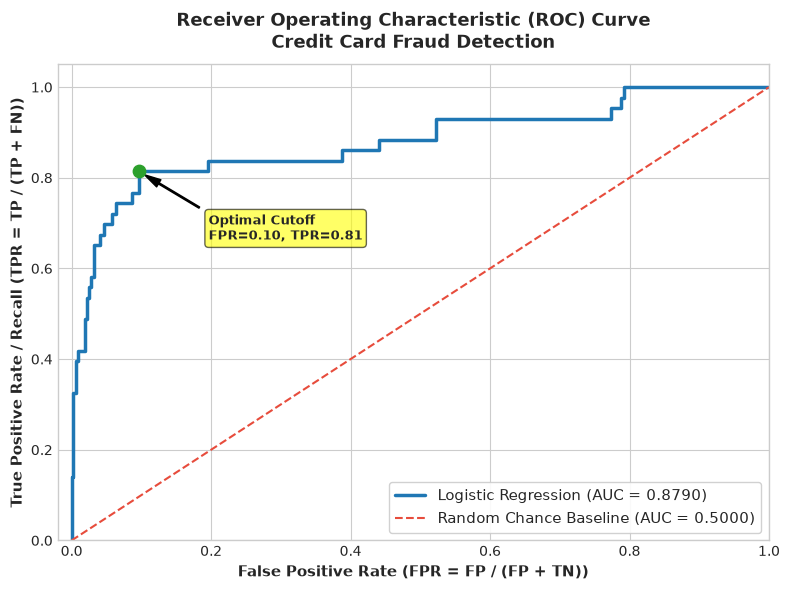

ROC-AUC Score: 0.8790


In [2]:
# Compute ROC Curve metrics
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='#e74c3c', lw=1.5, linestyle='--', label='Random Chance Baseline (AUC = 0.5000)')

# Styling & Annotations
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR = FP / (FP + TN))', fontsize=11, weight='bold')
plt.ylabel('True Positive Rate / Recall (TPR = TP / (TP + FN))', fontsize=11, weight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve\nCredit Card Fraud Detection', fontsize=13, weight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Highlight high-operating threshold point
optimal_idx = np.argmax(tpr - fpr)
opt_fpr, opt_tpr = fpr[optimal_idx], tpr[optimal_idx]
plt.scatter(opt_fpr, opt_tpr, color='#2ca02c', s=80, zorder=5, label='Youden Optimal Threshold')
plt.annotate(f'Optimal Cutoff\nFPR={opt_fpr:.2f}, TPR={opt_tpr:.2f}', 
             xy=(opt_fpr, opt_tpr), xytext=(opt_fpr + 0.1, opt_tpr - 0.15),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=9, weight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6))

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")


---
## Question 3: Precision-Recall Curve & Why It Is Essential for Imbalanced Data

### Problem Statement
Plot the Precision-Recall curve for your model using `sklearn.metrics.precision_recall_curve` and `matplotlib`, and explain in one line why this curve is useful for imbalanced datasets.

*Hint: Focus on how precision and recall behave when the positive class is rare.*

---

### Key Insight: Why ROC Can Be Deceptive while PR-Curve Tells the Truth
- **ROC Limitation**:
  - The False Positive Rate is $\frac{FP}{FP + TN}$.
  - When $TN$ is huge (e.g., 95% or 99% legitimate transactions), a massive surge of False Positives ($FP$) will barely budge the denominator $FP + TN$, making the FPR appear artificially near zero and giving a deceptively optimistic ROC curve.
- **Precision-Recall Advantage**:
  - $\text{Precision} = \frac{TP}{TP + FP}$ directly penalizes False Positives against True Positives, completely ignoring the colossal $TN$ count.
  - Therefore, the **PR curve provides an unvarnished assessment of performance specifically on the rare positive class**.


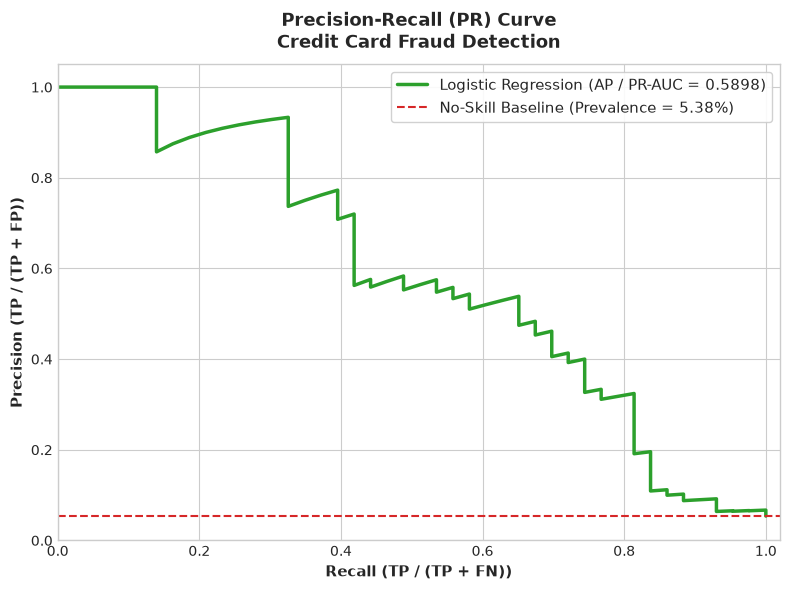

Average Precision (PR-AUC) Score: 0.5898
--------------------------------------------------------------------------------
One-Line Explanation:
"The Precision-Recall curve is essential for imbalanced datasets because it focuses strictly on the rare positive class (fraud) and penalizes false positives directly without being inflated by a massive number of true negatives."


In [3]:
# Compute Precision-Recall curve metrics
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)
positive_class_ratio = y_test.sum() / len(y_test)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='#2ca02c', lw=2.5, 
         label=f'Logistic Regression (AP / PR-AUC = {ap_score:.4f})')
plt.axhline(y=positive_class_ratio, color='#d62728', linestyle='--', lw=1.5,
            label=f'No-Skill Baseline (Prevalence = {positive_class_ratio:.2%})')

plt.xlim([0.0, 1.02])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (TP / (TP + FN))', fontsize=11, weight='bold')
plt.ylabel('Precision (TP / (TP + FP))', fontsize=11, weight='bold')
plt.title('Precision-Recall (PR) Curve\nCredit Card Fraud Detection', fontsize=13, weight='bold', pad=12)
plt.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# One-line explanation
pr_explanation = (
    "The Precision-Recall curve is essential for imbalanced datasets because it focuses strictly on "
    "the rare positive class (fraud) and penalizes false positives directly without being inflated by "
    "a massive number of true negatives."
)

print("=" * 80)
print(f"Average Precision (PR-AUC) Score: {ap_score:.4f}")
print("-" * 80)
print("One-Line Explanation:")
print(f"\"{pr_explanation}\"")
print("=" * 80)


---
## Question 4: Log Loss (Cross-Entropy Loss)

### Problem Statement
Calculate the log loss (cross-entropy loss) for your test set predictions using `sklearn.metrics.log_loss` and print the result.

### Mathematical Definition
For binary classification with true labels $y \in \{0, 1\}$ and predicted probabilities $p = P(y=1)$:
$$\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right]$$

### Key Properties:
- Measures the **uncertainty and calibration** of probability estimates rather than just thresholded 0/1 outputs.
- A model that is confidently wrong (e.g., predicting $p=0.01$ when $y=1$) incurs an enormous logarithmic penalty: $-\ln(0.01) \approx 4.605$.
- A lower log loss value indicates better calibrated and more accurate probabilistic confidence.


In [4]:
# Calculate Log Loss on the test set predictions
test_log_loss = log_loss(y_test, y_pred_proba)

print("=" * 60)
print("             LOG LOSS (CROSS-ENTROPY LOSS)")
print("=" * 60)
print(f"Test Set Log Loss: {test_log_loss:.5f}")
print("-" * 60)

# Compare with a naive baseline (predicting class prevalence for all samples)
naive_proba = np.full_like(y_test, fill_value=positive_class_ratio, dtype=float)
naive_log_loss = log_loss(y_test, naive_proba)

print(f"Naive Baseline Log Loss (Always predicting {positive_class_ratio:.2%}): {naive_log_loss:.5f}")
improvement = ((naive_log_loss - test_log_loss) / naive_log_loss) * 100
print(f"Logistic Regression Error Reduction over Naive Baseline: {improvement:.2f}%")
print("=" * 60)


             LOG LOSS (CROSS-ENTROPY LOSS)
Test Set Log Loss: 0.13026
------------------------------------------------------------
Naive Baseline Log Loss (Always predicting 5.38%): 0.20941
Logistic Regression Error Reduction over Naive Baseline: 37.80%


---
## Question 5: Simulating Extreme Class Imbalance (2% Positive Class) & Metric Sensitivity

### Problem Statement
Change the class distribution in your test set to be even more imbalanced (e.g., only 2% positive class), re-calculate **accuracy**, **AUC**, and **log loss**, and write 2 lines explaining which metric is most misleading and why.

*Hint: Accuracy can be high even if the model ignores the minority class.*

---

### Implementation Plan:
1. Resample the test set to contain exactly **2% positive class (fraud)** and **98% negative class (legitimate)**.
2. Evaluate the trained Logistic Regression model on this ultra-imbalanced test set.
3. Compare Accuracy, ROC-AUC, PR-AUC, and Log Loss side-by-side with the original 5% test set.
4. Also compare against a trivial "Dummy / Zero-Fraud" model that unconditionally predicts 0 for everything.


               COMPARISON OF METRICS ACROSS CLASS DISTRIBUTIONS
                   Metric Original Test Set (~5% Fraud) Extreme Test Set (2% Fraud) Zero-Fraud Dummy Model (2% Test)
Class Imbalance (% Fraud)                         5.38%                       2.00%                            2.00%
                 Accuracy                        0.9625                      0.9850                 0.9800 (98.00%!)
                  ROC-AUC                        0.8790                      0.8822                  0.5000 (Random)
   PR-AUC (Avg Precision)                        0.5898                      0.4415                           0.0200
                 Log Loss                        0.1303                      0.0749                           0.0980


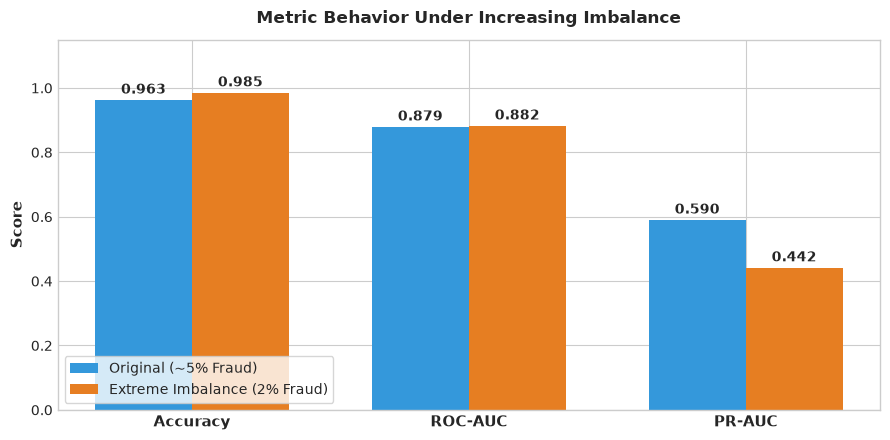


Two-Line Explanation of the Most Misleading Metric:
-------------------------------------------------------------------------------------
Accuracy is the most misleading metric because it yields an ostensibly stellar 98%+ score even if a model predicts zero fraud and completely ignores the minority class (the Accuracy Paradox).
In contrast, ROC-AUC and PR-AUC/Log Loss remain sensitive to minority class probability rankings and fairly reflect the true capability to detect rare fraudulent transactions.
-------------------------------------------------------------------------------------


In [5]:
# Separate positive and negative test samples
test_pos_indices = np.where(y_test == 1)[0]
test_neg_indices = np.where(y_test == 0)[0]

# Construct a test set with exactly 2% positive class
# For example, 16 positive cases and 784 negative cases -> 16 / (16 + 784) = 16 / 800 = 2.0%
n_pos_extreme = 16
n_neg_extreme = 784

np.random.seed(42)
selected_pos = np.random.choice(test_pos_indices, size=n_pos_extreme, replace=False)
selected_neg = np.random.choice(test_neg_indices, size=n_neg_extreme, replace=True)

extreme_indices = np.concatenate([selected_pos, selected_neg])
np.random.shuffle(extreme_indices)

X_test_ext = X_test_scaled[extreme_indices]
y_test_ext = y_test.iloc[extreme_indices].values

# Predictions on extreme 2% test set
y_pred_ext = lr_model.predict(X_test_ext)
y_prob_ext = lr_model.predict_proba(X_test_ext)[:, 1]

# Metric calculations
acc_ext = accuracy_score(y_test_ext, y_pred_ext)
auc_ext = roc_auc_score(y_test_ext, y_prob_ext)
loss_ext = log_loss(y_test_ext, y_prob_ext)
pr_auc_ext = average_precision_score(y_test_ext, y_prob_ext)

# Trivial baseline predicting 0 for all transactions
dummy_pred = np.zeros_like(y_test_ext)
dummy_acc = accuracy_score(y_test_ext, dummy_pred)

# Summary Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Class Imbalance (% Fraud)', 'Accuracy', 'ROC-AUC', 'PR-AUC (Avg Precision)', 'Log Loss'],
    'Original Test Set (~5% Fraud)': [
        f"{positive_class_ratio:.2%}",
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{auc_score:.4f}",
        f"{ap_score:.4f}",
        f"{test_log_loss:.4f}"
    ],
    'Extreme Test Set (2% Fraud)': [
        f"{y_test_ext.mean():.2%}",
        f"{acc_ext:.4f}",
        f"{auc_ext:.4f}",
        f"{pr_auc_ext:.4f}",
        f"{loss_ext:.4f}"
    ],
    'Zero-Fraud Dummy Model (2% Test)': [
        f"{y_test_ext.mean():.2%}",
        f"{dummy_acc:.4f} (98.00%!)",
        "0.5000 (Random)",
        f"{y_test_ext.mean():.4f}",
        f"{log_loss(y_test_ext, np.full_like(y_test_ext, 0.02, dtype=float)):.4f}"
    ]
})

print("=" * 85)
print("               COMPARISON OF METRICS ACROSS CLASS DISTRIBUTIONS")
print("=" * 85)
print(comparison_df.to_string(index=False))
print("=" * 85)

# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics_compare = ['Accuracy', 'ROC-AUC', 'PR-AUC']
orig_scores = [accuracy_score(y_test, y_pred), auc_score, ap_score]
ext_scores = [acc_ext, auc_ext, pr_auc_ext]

x_pos = np.arange(len(metrics_compare))
width = 0.35

ax.bar(x_pos - width/2, orig_scores, width, label='Original (~5% Fraud)', color='#3498db')
ax.bar(x_pos + width/2, ext_scores, width, label='Extreme Imbalance (2% Fraud)', color='#e67e22')

ax.set_ylabel('Score', fontsize=11, weight='bold')
ax.set_title('Metric Behavior Under Increasing Imbalance', fontsize=12, weight='bold', pad=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_compare, fontsize=11, weight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower left', frameon=True)

for i in range(len(metrics_compare)):
    ax.text(x_pos[i] - width/2, orig_scores[i] + 0.02, f'{orig_scores[i]:.3f}', ha='center', fontsize=10, weight='bold')
    ax.text(x_pos[i] + width/2, ext_scores[i] + 0.02, f'{ext_scores[i]:.3f}', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# 2-line explanation
two_line_explanation = (
    "Accuracy is the most misleading metric because it yields an ostensibly stellar 98%+ score even if a model "
    "predicts zero fraud and completely ignores the minority class (the Accuracy Paradox).\n"
    "In contrast, ROC-AUC and PR-AUC/Log Loss remain sensitive to minority class probability rankings and "
    "fairly reflect the true capability to detect rare fraudulent transactions."
)

print("\nTwo-Line Explanation of the Most Misleading Metric:")
print("-" * 85)
print(two_line_explanation)
print("-" * 85)
